In [1]:
import sys, common, pickle, collections, numpy
import pandas as pd
import matplotlib.pyplot as plt
from logJosh import Tee
import prince

# Functions

In [7]:
def parsePickleFile(pickleFile):
    """
    Given Liam's pickle file, will output a dict of the format:
    {bc:{readID:{position:edit}}} where position has to be an A in the ref
    """
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                seq=refSeq[ii]
                edit=editString[ii]
                if seq=='A' and edit!='2' and absIdx<=695:
                    ##695 is where the RT primer binds--anything past this
                    ##is artifact.
                    bb[barCode][readID][absIdx]=int(edit)
    ##
    return bb

def formatForMCA(dataDict,numReads,minEditFreq):
    """
    dataDict={bc:{readID:{position:1/0}}}
    numReads is an integer.
    minEditFreq is a frequency (e.g., 0.7)
    Will sort each bc's readIDs by longest -> shortest, and then select the
    numReads longest reads with at least minEditFreq of 1's
    Will then convert to a list-of-lists like:
    [[0,1,1,0,...,1],
     [1,1,0,1,...,1],
     ...
     [1,0,0,0,...,0]]
     where each row represents a different readID. Will also return a list
     of bcs, which are the row labels.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    temp2.append((bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[1]:
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    for entry in aa:
        ##record the bc
        listOfBCs.append(entry[0])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            if k in entry[1]:
                v=entry[1][k]
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs

def doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run MCA and plot the first two components.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##initialize mca
    mca = prince.MCA(n_components=5, n_iter=5, \
        copy=True, check_input=True, engine='sklearn', \
        random_state=42)
    ##
    mca_fit = mca.fit(X)
    X_mca = mca_fit.transform(X)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    ##add the labels
    X_mca['label'] = labels.values
    ##print some results
    print(mca.eigenvalues_summary)
    print(mca.column_coordinates(X))
    ##
    for ii in range(4):
        ##plot the data
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_mca['label'].unique():
            subset = X_mca[X_mca['label'] == label]
            ax.scatter(subset[ii], subset[ii+1], label=label)
        ##set axis labels
        ax.set_title('MCA of Binary Vectors')
        ax.set_xlabel('MCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('MCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()

# Load Data

In [19]:
from pathlib import Path
pickleFile = Path('/data16/liam/working/data/alignments/250509_JANP-112_LT/250703_pickles/merged_barcodes_nanoluc_translatable.pickle')
numReads = 50
minEdit = 0.8
outPrefix = Path('/data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing/260204_test')

## Run MCA

4
200
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.049         4.92%                      4.92%
1              0.037         3.69%                      8.61%
2              0.033         3.31%                     11.91%
3              0.026         2.56%                     14.47%
4              0.023         2.30%                     16.77%
                  0         1         2         3         4
A0__0.0   -0.734032 -0.087739  0.034460 -0.450994 -0.423432
A0__1.0    0.060093  0.037046 -0.042017  0.013502  0.070871
A1__0.0    0.307722 -0.667390  0.541626 -0.691629  0.036962
A1__1.0   -0.018939  0.015908 -0.007620  0.011728 -0.001220
A2__0.0   -0.316604  0.152302 -0.142491 -0.432589  0.142447
...             ...       ...       ...       ...       ...
A234__1.0 -0.004574 -0.006316  0.004595  0.011361  0.000324
A235__0.0  0.037454  1.072710 -0.601980 -0.190111 -0.178762
A235__1.0 -0.012368 

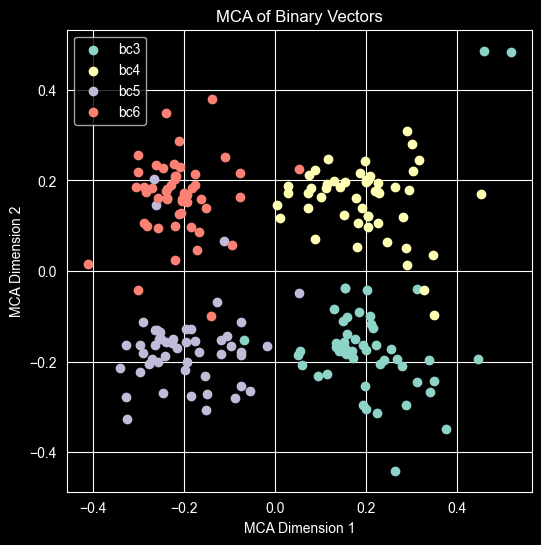

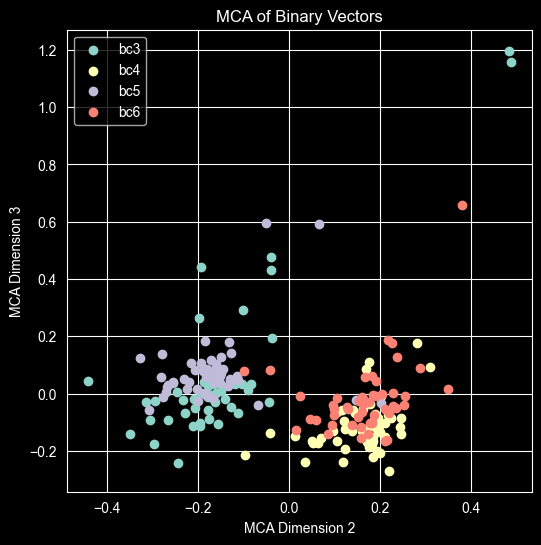

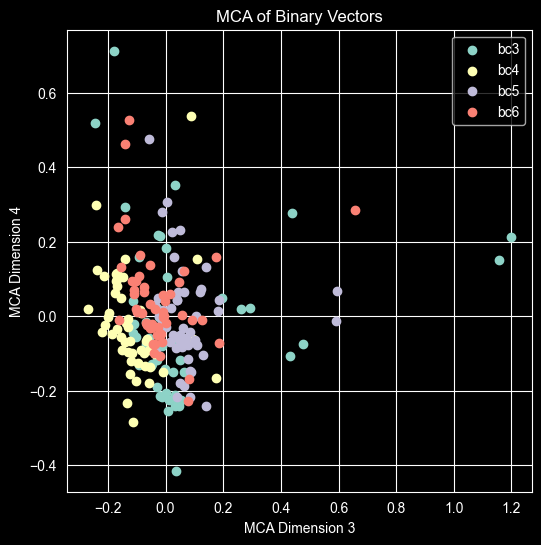

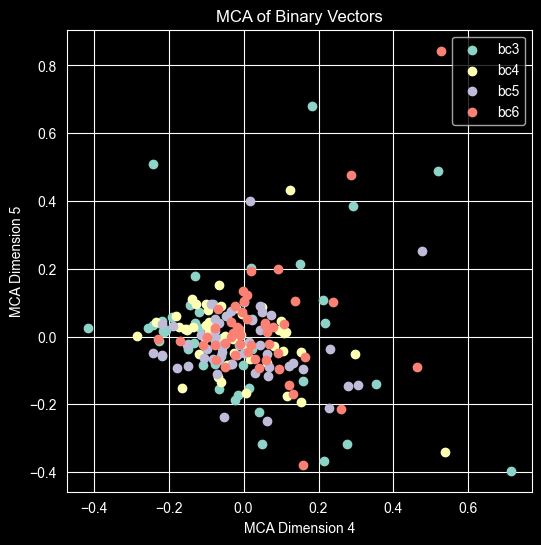

In [9]:
dataDict=parsePickleFile(pickleFile)
print(len(dataDict))
##
matrixOfEdits,listOfBCs=formatForMCA(dataDict,int(numReads),\
    float(minEdit))
print(len(matrixOfEdits))
##
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix)

## Grabbed MCA reads

In [10]:
def formatForMCA2(dataDict,numReads,minEditFreq):
    """
    same as formatForMCA but will return a list of Read IDs as well.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    temp2.append((readID,bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[2]:##2 b/c readID, bc, positDict
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    listOfReadIDs=[]
    for entry in aa:
        ##record the readID
        listOfReadIDs.append(entry[0])
        ##record the bc
        listOfBCs.append(entry[1])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            if k in entry[2]:##2 b/c readID, bc, positDict
                v=entry[2][k]
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs,listOfReadIDs

4
200
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.049         4.92%                      4.92%
1              0.037         3.69%                      8.61%
2              0.033         3.31%                     11.91%
3              0.026         2.56%                     14.47%
4              0.023         2.30%                     16.77%
                  0         1         2         3         4
A0__0.0   -0.734032 -0.087739  0.034460 -0.450994 -0.423432
A0__1.0    0.060093  0.037046 -0.042017  0.013502  0.070871
A1__0.0    0.307722 -0.667390  0.541626 -0.691629  0.036962
A1__1.0   -0.018939  0.015908 -0.007620  0.011728 -0.001220
A2__0.0   -0.316604  0.152302 -0.142491 -0.432589  0.142447
...             ...       ...       ...       ...       ...
A234__1.0 -0.004574 -0.006316  0.004595  0.011361  0.000324
A235__0.0  0.037454  1.072710 -0.601980 -0.190111 -0.178762
A235__1.0 -0.012368 

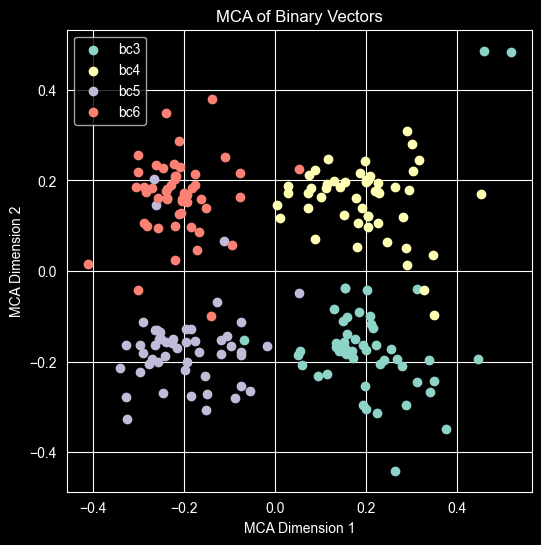

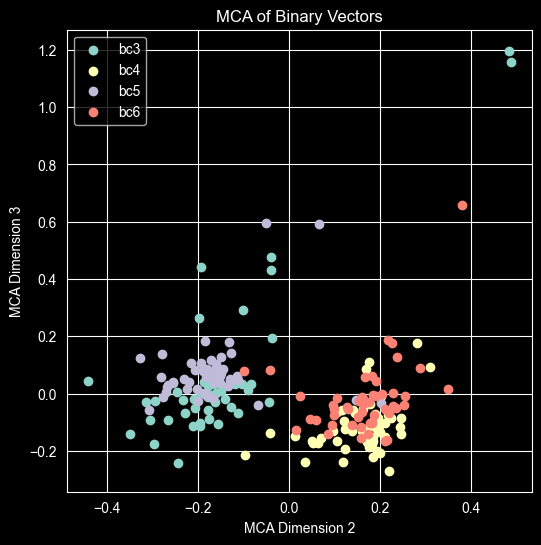

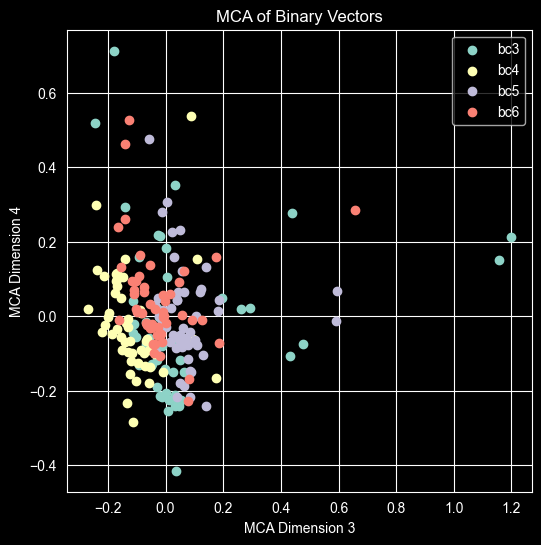

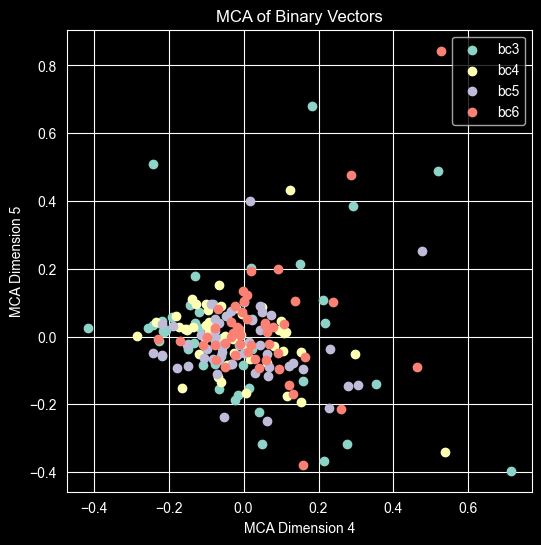

In [11]:
dataDict=parsePickleFile(pickleFile)
print(len(dataDict))
##
matrixOfEdits,listOfBCs,listOfReadIDs=formatForMCA2(dataDict,int(numReads),\
    float(minEdit))
print(len(matrixOfEdits))
##
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix)

In [12]:
print("listOfReadIDs: ", len(listOfReadIDs))

listOfReadIDs:  200


# Let's try PCA on the same set of reads

## New Functions

In [37]:
def parsePickleFileForPCA(pickleFile):
    """
    same as parsePickleFile but will return a dict with all positions, not just A's:
    """
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                edit=editString[ii]
                seq=refSeq[ii]
                if edit !='2' and absIdx<=695:
                    if seq == 'A':
                        bb[barCode][readID][absIdx]=(int(edit), 1)##1 indicates A
                    else:
                        bb[barCode][readID][absIdx]=(int(edit), 0)##0 indicates not A
    ##
    return bb

def formatForPCA2(dataDict,numReads,minEditFreq):
    """
    modified for new dataDict format, where each position is a tuple of (edit, isA)
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum([v[0] for v in positDict.values()])/sum([v[1] for v in positDict.values()]) >= minEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum([v[0] for v in positDict.values()])/sum([v[1] for v in positDict.values()]) >= minEditFreq:
                    temp2.append((readID,bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
        ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[2]:##2 b/c readID, bc, positDict
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    listOfReadIDs=[]
    for entry in aa:
        ##record the readID
        listOfReadIDs.append(entry[0])
        ##record the bc
        listOfBCs.append(entry[1])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            if k in entry[2]:##2 b/c readID, bc, positDict
                v=entry[2][k][0]##0 b/c edit value
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs,listOfReadIDs

def smoothAndImpute(matrixOfEdits):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. Will smooth the data by replacing each value with
    the average of itself and its two neighbors on either side. Will then
    impute any remaining nans with the column mean.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##smooth the data
    X_smooth = X.rolling(window=5, min_periods=1, center=True).mean()
    ##impute remaining nans with column mean
    X_imputed = X_smooth.fillna(X_smooth.mean())
    ##
    return X_imputed

def doPCAandPlot(matrixOfEdits,listOfBCs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run PCA and plot the first two components.

    input: smoothed and imputed matrix of edits (i.e., output of smoothAndImpute), so pandas DF with no nans.
    """
    # run PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=5, random_state=42)
    X_pca = pca.fit_transform(matrixOfEdits)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    ##add the labels    X_pca_df = pd.DataFrame(X_pca, columns=['PC%s'%(ii+1) for ii in range(X_pca.shape[1])])
    X_pca_df = pd.DataFrame(X_pca, columns=['PC%s'%(ii+1) for ii in range(X_pca.shape[1])])
    X_pca_df['label'] = labels.values
    ##print some results
    print("Explained variance ratio: ", pca.explained_variance_ratio_)
    print("PCA components: ", pca.components_)
    ##plot the data
    for ii in range(4):
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_pca_df['label'].unique():
            subset = X_pca_df[X_pca_df['label'] == label]
            ax.scatter(subset['PC%s'%(ii+1)], subset['PC%s'%(ii+2)], label=label)
        ##set axis labels
        ax.set_title('PCA of Binary Vectors')
        ax.set_xlabel('PCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('PCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.PCA.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()



## Run PCA

4
200
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.017         4.69%                      4.69%
1              0.013         3.56%                      8.24%
2              0.012         3.33%                     11.57%
3              0.010         2.87%                     14.44%
4              0.008         2.29%                     16.73%
                  0         1         2         3         4
A0__0.0    0.141216 -0.087931 -0.079150 -0.115043  0.173470
A1__0.0    0.074880 -0.109894 -0.076481 -0.113902  0.158047
A2__0.0    0.036230 -0.007699  0.006297 -0.030902  0.027371
A3__0.0    0.028045  0.021171 -0.006439 -0.005270  0.014768
A4__0.0    0.018537  0.009627 -0.000238 -0.006874  0.011849
...             ...       ...       ...       ...       ...
A693__0.0  0.125750 -0.810116  0.583699 -1.011385  0.960355
A693__1.0 -0.010901  0.007647 -0.003802  0.016226 -0.016818
A694__0.0 -0.467542 

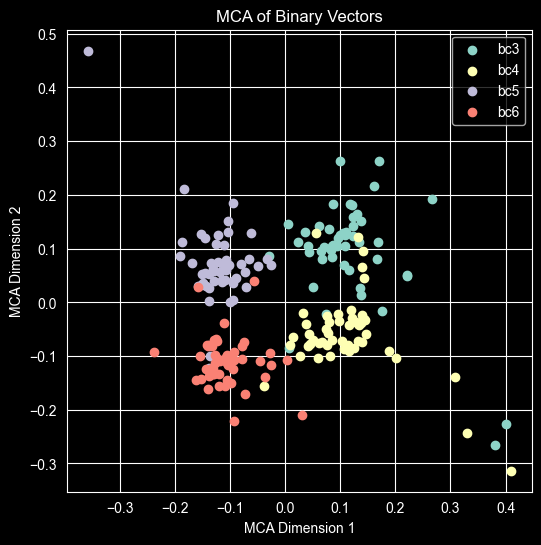

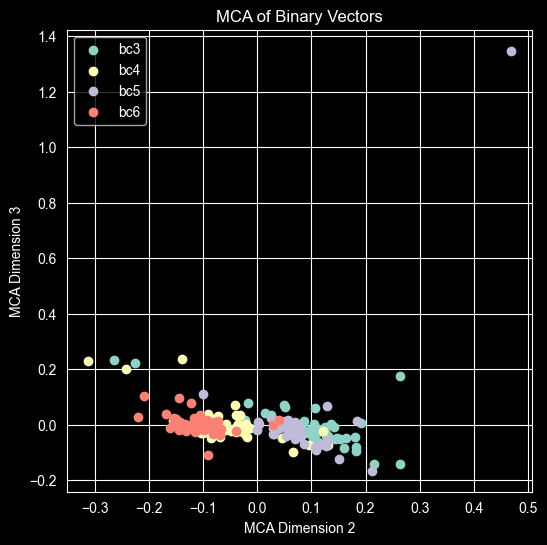

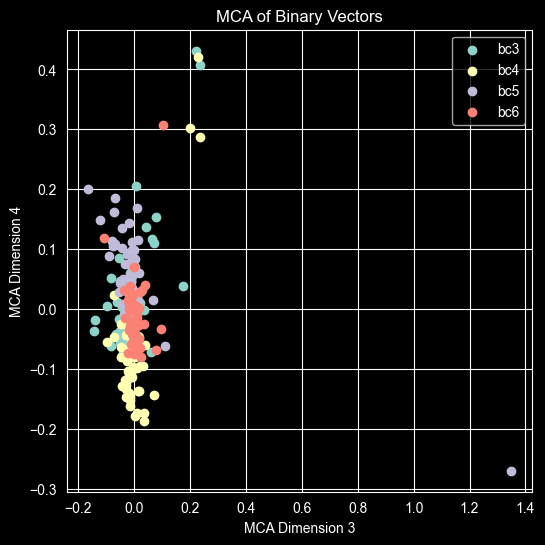

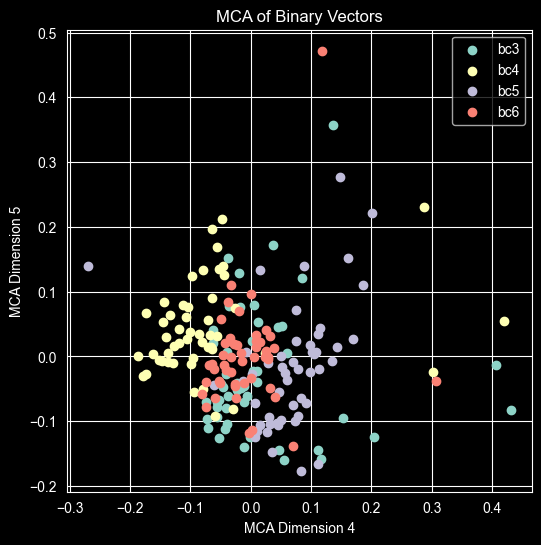

In [30]:
dataDict=parsePickleFileForPCA(pickleFile)
print(len(dataDict))
##
matrixOfEdits,listOfBCs,listOfReadIDs=formatForPCA2(dataDict,int(numReads),\
    float(minEdit))
print(len(matrixOfEdits))
##
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix)

In [32]:
matrixOfEdits_smooth_imputed = smoothAndImpute(matrixOfEdits)

In [39]:
# matrixOfEdits_smooth_imputed

Explained variance ratio:  [0.34269458 0.22550949 0.03009255 0.02668267 0.02253741]
PCA components:  [[-2.33400736e-18  4.81727939e-25  2.39562291e-25 ...  1.19887436e-03
   1.70176597e-03  0.00000000e+00]
 [ 5.74932948e-17  5.07056859e-24  5.61473442e-24 ...  9.29578726e-03
   9.99738706e-04 -0.00000000e+00]
 [ 1.81436127e-16  2.44817992e-17  1.98957938e-17 ...  3.16165776e-03
   1.21124242e-02 -0.00000000e+00]
 [ 1.09078923e-16  2.20480323e-16 -1.72818920e-17 ... -2.45844146e-03
  -2.11674939e-02 -0.00000000e+00]
 [ 3.25065341e-17 -3.58082129e-16  1.31478214e-17 ... -2.98925822e-03
   7.12703332e-03 -0.00000000e+00]]


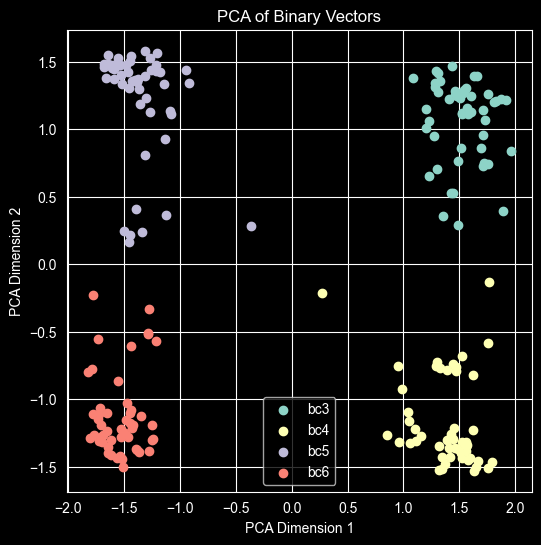

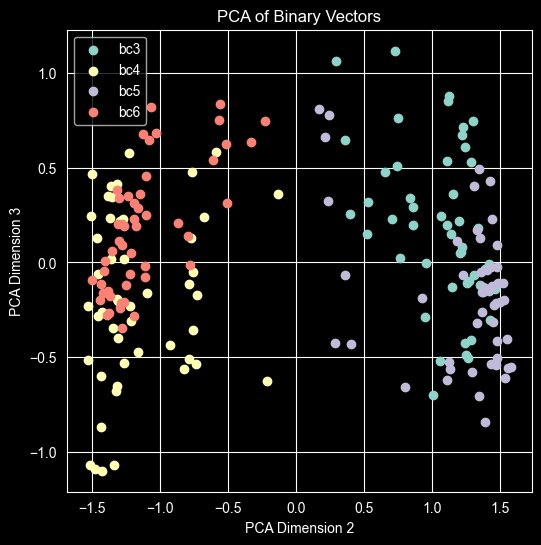

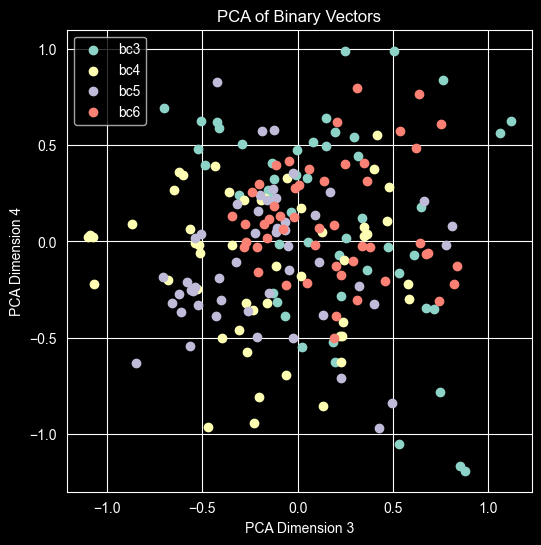

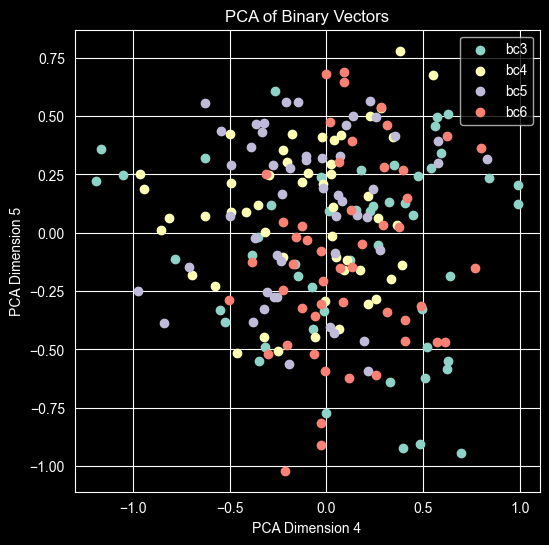

In [38]:
doPCAandPlot(matrixOfEdits_smooth_imputed, listOfBCs, outPrefix.with_suffix('.PCA_smooth_imputed'))

# Let's try doing PCA in chunks
### Holding everything in RAM is not feasible on Tincan, so let's try parsing the data in chunks and building the matrix iteratively. Will need to modify the functions above to accommodate this.

### Load data from parquet directory

In [43]:
working_dir = Path('/data16/liam/working/data/alignments/250509_JANP-112_LT/parquets')

In [54]:
import importlib, incremental_pca_pipeline
importlib.reload(incremental_pca_pipeline)
from incremental_pca_pipeline import run_pipeline

ipca, pc_files, barcodes = run_pipeline(
    raw_parquet_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/parquets",
    edit_matrix_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/edit_matrix",   # intermediate, can delete after
    output_dir      = "/data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing",
    num_reads       = 50,
    min_edit_freq   = 0.8,
    n_components    = 5
)

[parse] 2 raw parquet file(s)
  [1/2] parsing merged_barcodes_nanoluc_translatable_chunk0.parquet
[debug] absolute_indices type after normalise: <class 'list'>, first 5 values: [0.0, 1.0, 2.0, 3.0, 4.0], value types: ['float', 'float', 'float', 'float', 'float']
  [2/2] parsing merged_barcodes_nanoluc_translatable_chunk1.parquet
[parse] 4 barcodes found
[parse] 228 reads selected after filtering
[parse] 696 unique genomic positions
  wrote edit_matrix_chunk0.parquet  (228 rows)
[parse] done — 1 edit-matrix parquet(s)

[stats] computing per-column means (Welford) …
[stats] done — 696 column means computed

[fit] fitting IncrementalPCA …
  partial_fit on edit_matrix_chunk0.parquet  (228 rows, 228 total)
[fit] done — 29.61% variance explained

[transform] projecting into PC space …
  edit_matrix_chunk0.parquet → edit_matrix_chunk0_pcs.npy  shape=(228, 5)
[transform] done — 1 file(s), 228 total reads

[plot]  4 plot(s), 4 label(s)
  saved → /data16/liam/working/data/alignments/250509_JANP-

In [71]:
import importlib, incremental_pca_pipeline
importlib.reload(incremental_pca_pipeline)
from incremental_pca_pipeline import run_pipeline

ipca, pc_files, barcodes = run_pipeline(
    raw_parquet_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/parquets",
    edit_matrix_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/edit_matrix",   # intermediate, can delete after
    output_dir      = "/data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing",
    num_reads       = 50,
    min_edit_freq   = 0.8,
    n_components    = 5
)

[parse] 2 raw parquet file(s)
  [1/2] parsing merged_barcodes_nanoluc_translatable_chunk0.parquet
[debug] absolute_indices type after normalise: <class 'list'>, first 5 values: [0.0, 1.0, 2.0, 3.0, 4.0], value types: ['float', 'float', 'float', 'float', 'float']
  [2/2] parsing merged_barcodes_nanoluc_translatable_chunk1.parquet
[parse] 4 barcodes found
[parse] 243 reads selected after filtering
[parse] 237 unique genomic positions
  wrote edit_matrix_chunk0.parquet  (243 rows)
[parse] done — 1 edit-matrix parquet(s)

[stats] computing per-column means (Welford) …
[stats] done — 237 column means computed

[fit] fitting IncrementalPCA …
  partial_fit on edit_matrix_chunk0.parquet  (243 rows, 243 total)
[fit] done — 66.40% variance explained

[transform] projecting into PC space …
  edit_matrix_chunk0.parquet → edit_matrix_chunk0_pcs.npy  shape=(243, 5)
[transform] done — 1 file(s), 243 total reads

[plot]  4 plot(s), 4 label(s)
  saved → /data16/liam/working/data/alignments/250509_JANP-

In [67]:
# How many reads per barcode are we selecting?
from collections import Counter
bc_counts = Counter(barcodes)
print(pd.Series(bc_counts).describe())

count     4.000000
mean     58.750000
std       9.742518
min      51.000000
25%      54.000000
50%      55.500000
75%      60.250000
max      73.000000
dtype: float64


In [76]:
# test window implementation
import importlib, incremental_pca_pipeline
importlib.reload(incremental_pca_pipeline)
from incremental_pca_pipeline import run_pipeline

ipca, pc_files, barcodes = run_pipeline(
    raw_parquet_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/parquets",
    edit_matrix_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/edit_matrix",   # intermediate, can delete after
    output_dir      = "/data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing",
    num_reads       = 50,
    min_edit_freq   = 0.8,
    n_components    = 5
)

[parse] 2 raw parquet file(s)
  [1/2] parsing merged_barcodes_nanoluc_translatable_chunk0.parquet
  [2/2] parsing merged_barcodes_nanoluc_translatable_chunk1.parquet
[parse] 4 barcodes found
[parse] 243 reads selected after filtering
[parse] 237 unique genomic positions
  wrote edit_matrix_chunk0.parquet  (243 rows)
[parse] done — 1 edit-matrix parquet(s)

[stats] computing per-column means (Welford) …
[stats] done — 237 column means computed

[fit] fitting IncrementalPCA …
  partial_fit on edit_matrix_chunk0.parquet  (243 rows, 243 total)
[fit] done — 66.40% variance explained

[transform] projecting into PC space …
  edit_matrix_chunk0.parquet → edit_matrix_chunk0_pcs.npy  shape=(243, 5)
[transform] done — 1 file(s), 243 total reads

[plot]  4 plot(s), 4 label(s)
  saved → /data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing/result_all_positions.PCA.0.1.png
  saved → /data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing/result_all_positions.PCA.1.2.png
  

# Trying the approach on a different dataset with more reads per barcode

# Load new data

In [1]:
import pyarrow.parquet as pq
from pathlib import Path
from incremental_pca_pipeline import _parse_read_row, _edit_freq

# # test window implementation
# import importlib, incremental_pca_pipeline
# importlib.reload(incremental_pca_pipeline)
import importlib, threePass_incremental_pca_pipeline
from threePass_incremental_pca_pipeline import run_pipeline
from incremental_pca_pipeline import run_pipeline

ipca, pc_files, barcodes = run_pipeline(
    raw_parquet_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/parquets",
    edit_matrix_dir = "/data16/liam/working/data/alignments/250509_JANP-112_LT/edit_matrix",   # intermediate, can delete after
    output_dir      = "/data16/liam/working/data/alignments/250509_JANP-112_LT/260223_pca_testing",
    num_reads       = 50,
    min_edit_freq   = 0.8,
    n_components    = 5
)

[parse] 2 raw parquet file(s)
  [1/2] parsing merged_barcodes_nanoluc_translatable_chunk0.parquet
  [2/2] parsing merged_barcodes_nanoluc_translatable_chunk1.parquet
[parse] 4 barcodes found
[parse] 243 reads selected after filtering
[parse] 237 unique genomic positions
  wrote edit_matrix_chunk0.parquet  (243 rows)
[parse] done — 1 edit-matrix parquet(s)

[stats] computing per-column means (Welford) …
[stats] done — 237 column means computed

[fit] fitting IncrementalPCA …
  partial_fit on edit_matrix_chunk0.parquet  (243 rows, 243 total)
[fit] done — 66.52% variance explained

[transform] projecting into PC space …
  edit_matrix_chunk0.parquet → edit_matrix_chunk0_pcs.npy  shape=(243, 5)
[transform] done — 1 file(s), 243 total reads

[plot]  4 plot(s), 4 label(s)
  saved → /data16/liam/working/data/alignments/250509_JANP-112_LT/260223_pca_testing/result_all_positions.PCA.0.1.png
  saved → /data16/liam/working/data/alignments/250509_JANP-112_LT/260223_pca_testing/result_all_positions.